In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
import uuid
import torch

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Step 1: Define System and Simulation Parameters
N = 64  # Number of BS antennas
K = 4   # Number of users
M = 4   # Number of RF chains
omega = 0.3  # Tradeoff weight

I_max = 120  # Maximum outer iterations
sigma_n2 = 1.0  # Noise variance
mu = 0.01  # Step size for analog precoder
lambda_ = 0.01  # Step size for digital precoder
L = 20  # Number of paths for channel

# Convert to tensors
omega_t = torch.tensor(omega, dtype=torch.float32, device=device)
sigma_n2_t = torch.tensor(sigma_n2, dtype=torch.float32, device=device)
mu_t = torch.tensor(mu, dtype=torch.float32, device=device)
lambda_t = torch.tensor(lambda_, dtype=torch.float32, device=device)

# Step 2: Define Sensing Parameters
P = 3  # Number of desired sensing angles
theta_d = np.array([-60, 0, 60]) * np.pi / 180  # Desired angles in radians
delta_theta = 5 * np.pi / 180  # Half beamwidth
theta_grid = np.linspace(-np.pi / 2, np.pi / 2, 181)  # Angular grid [-90, 90] degrees
B_d = np.zeros(len(theta_grid))  # Desired beampattern
for t, theta_t in enumerate(theta_grid):
    for theta_p in theta_d:
        if abs(theta_t - theta_p) <= delta_theta:
            B_d[t] = 1

# Convert to tensors
theta_d_t = torch.tensor(theta_d, dtype=torch.float32, device=device)
theta_grid_t = torch.tensor(theta_grid, dtype=torch.float32, device=device)
B_d_t = torch.tensor(B_d, dtype=torch.float32, device=device)

# Wavenumber and antenna spacing
lambda_wave = 1  # Wavelength (normalized)
k = 2 * np.pi / lambda_wave
d = lambda_wave / 2  # Antenna spacing

k_t = torch.tensor(k, dtype=torch.float32, device=device)
d_t = torch.tensor(d, dtype=torch.float32, device=device)

In [11]:
from lib.support_functions_torch import compute_avg_beampattern_mse, compute_psi, generate_channel_torch_batch, proposed_initialization_torch, run_pga_torch
from lib.dnn import UPGANet

num_realizations = 100

# === SNR range ===
snr_db_values = np.arange(0, 13, 2)
mse_pga = []
mse_zf = []
mse_upganet = []

# Load trained UPGANet model
trained_model = UPGANet(N, M, K, omega, I_max=I_max, J=1).to(device)
trained_model.load_state_dict(torch.load("upganet_J1_final.pth", map_location=device))
trained_model.eval()

# === Main Loop ===
for snr_db in snr_db_values:
    print(f"\nEvaluating at SNR = {snr_db:.1f} dB")
    P_BS = sigma_n2 * 10**(snr_db / 10)
    Psi = compute_psi(snr_db)
    Psi = torch.tensor(compute_psi(snr_db), dtype=torch.cfloat, device=device)

    P_BS = sigma_n2 * 10**(snr_db / 10)
    P_BS_t = torch.tensor(P_BS, dtype=torch.float32, device=device)

    mse_pga_realizations = []
    mse_zf_realizations = []
    mse_upganet_realizations = []

    H_batch = generate_channel_torch_batch(N, M, L=20, batch_size=num_realizations, device=device)

    for r in range(num_realizations):
        H_ch = H_batch[r]
        # snr_db = torch.tensor(snr_max, device=device)
        
        A0, D0 = proposed_initialization_torch(H_ch, theta_d_t, N, M, K, P_BS_t, device=device)

        # === (1) PGA Hybrid Precoding ===
        _, R, A, D = run_pga_torch(H_ch, A0, D0, 1, I_max, mu, lambda_, omega, sigma_n2_t, Psi, P_BS_t, device)

        # Calculate MSE for PGA
        mse_pga_sample = compute_avg_beampattern_mse(A, D, B_d_t, theta_grid_t, device)
        mse_pga_realizations.append(mse_pga_sample)

        # # === (2) UPGANet Hybrid Precoding ===
        with torch.no_grad():
            A, D = trained_model(H_ch, A0, D0, Psi, sigma_n2_t, P_BS_t)

        # Calculate MSE for UPGANet
        mse_upganet_sample = compute_avg_beampattern_mse(A, D, B_d_t, theta_grid_t, device)
        mse_upganet_realizations.append(mse_upganet_sample)


        # # === (2) ZF Baseline ===
        # # Fully digital precoder: D_zf = sqrt(P_BS) * Hᴴ (H Hᴴ)⁻¹
        # Hh = H.conj().T
        # D_zf = np.sqrt(P_BS) * (Hh @ np.linalg.inv(H @ Hh)) / np.linalg.norm(Hh @ np.linalg.inv(H @ Hh), 'fro')
        # A_zf = np.eye(N, dtype=np.complex64)  # fully digital = no analog constraint

        # # === Convert to torch ===
        # A_zf_t = torch.tensor(A_zf, dtype=torch.complex64, device=device)
        # D_zf_t = torch.tensor(D_zf, dtype=torch.complex64, device=device)

        # # === Compute MSE for ZF ===
        # mse_zf_sample = compute_avg_beampattern_mse(A_zf_t, D_zf_t, B_d_t, theta_grid_t, device)
        # mse_zf_realizations.append(mse_zf_sample)

    # === Average across realizations (linear domain) ===
    mse_pga.append(np.mean(mse_pga_realizations))
    mse_upganet.append(np.mean(mse_upganet_realizations))
    # mse_zf.append(np.mean(mse_zf_realizations))


Evaluating at SNR = 0.0 dB


/home/swengapp23/OneDrive/PHD Thesis/mimo_jcas_system/lib/support_functions_torch.py:64: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phase = 1j * torch.pi * n * torch.sin(torch.tensor(theta, device=device))



Evaluating at SNR = 2.0 dB

Evaluating at SNR = 4.0 dB

Evaluating at SNR = 6.0 dB

Evaluating at SNR = 8.0 dB

Evaluating at SNR = 10.0 dB

Evaluating at SNR = 12.0 dB


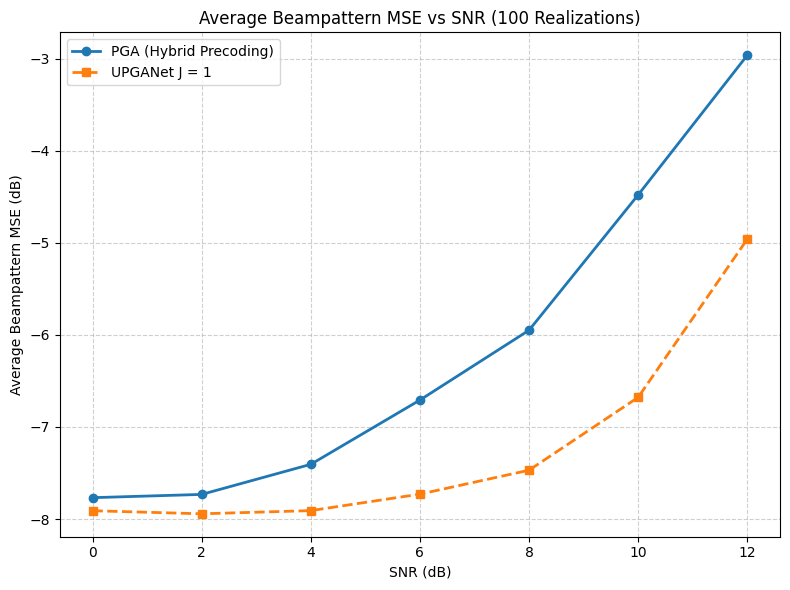

In [12]:

# mse_upganet_db = 10 * np.log10(np.array(mse_upganet_linear) + 1e-12)
# mse_zf_db = 10 * np.log10(np.array(mse_zf_linear) + 1e-12)

# === Plot ===
plt.figure(figsize=(8,6))
plt.plot(snr_db_values, mse_pga, 'o-', linewidth=2, label='PGA (Hybrid Precoding)')
plt.plot(snr_db_values, mse_upganet, 's--', linewidth=2, label='UPGANet J = 1')
plt.xlabel('SNR (dB)')
plt.ylabel('Average Beampattern MSE (dB)')
plt.title(f'Average Beampattern MSE vs SNR ({num_realizations} Realizations)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()